# Final Project - Text Analysis and Classification

Dataset: Amazon Product Reviews (Reviews.csv)
Goal: Text preprocessing, feature extraction, visualization, and multi-class classification.

In [17]:
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, ParameterGrid

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score


In [2]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('omw-1.4', quiet=True)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# PHẦN A — TIỀN XỬ LÝ & PHÂN TÍCH VĂN BẢN 

## A1. Khám phá dữ liệu ban đầu

### Câu A1:

In [3]:
DATA_PATH = "data/Reviews.csv"
df_raw = pd.read_csv(DATA_PATH)
df_raw.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,positive
0,467269,B0016888TU,A2582KMXLK2P06,B. E Jackson,0,0,5,1350950400,mini delights,Can you think of a more appropriate or delight...,1
1,44373,B000F6STQG,A3F3B1JPACN215,Michael G. Lustig,1,1,3,1186358400,Too much salmon,I never thought I'd say this about a spread bu...,0
2,27170,B002UQCY88,A2JWGBR1F593II,Mom of Four,0,0,2,1303862400,Not happy with this product...,The crackers were all broken up and in crumbs....,0
3,154992,B0047E2I3M,A100UZGZNZ9ZYN,"Nomadic PC User ""Chef""",2,5,1,1310342400,Something seems to be very dishonest,After receiving the package I was hoping my th...,0
4,496982,B005HG9ET0,#oc-RODMQLZAXFCUG,"Tim Drake ""Author and Journalist""",1,1,5,1343865600,Healthy Water!,It looks like water. It smells like water. It ...,1
5,430318,B005K4Q1T0,ADNABCDGM22PU,Tammy,0,0,5,1327017600,Yummy,Oh so good. The first cup I had was on the med...,1
6,274973,B0000CDBPT,A3A7J2DZQYY7DT,B. Arredondo,7,7,5,1111968000,Magic Blackened Seasong,I can't tell you that I've tried all of Chef P...,1
7,292242,B000VK08OC,A2SH07MBJ9PEG3,"Matthew Scarborough ""Scarbby""",11,11,5,1240790400,Manuka Honey great for healing leg ulcer after...,I recently had surgery to remove a dead vain i...,1
8,223424,B002QGK2V8,AD59BI0J8W5Z5,Mary OBrien,1,1,5,1259452800,One of my Top Favorites,In my personal rating system this coffee got a...,1
9,478478,B0092X7BLC,A3IE8OGKQ0OCTE,"Clifton Watson ""Jus' a simple man. Nothin' sp...",3,10,5,1211760000,A Surprising Blend of Bean and Apple,I wasn't sure what to expect from this Jelly B...,1


### Câu A2:

In [4]:
df = df_raw[["Text", "Score"]].copy()
df = df.dropna(subset=["Text", "Score"])
df = df[df["Text"].str.strip().astype(bool)]

def score_to_label(score):
    if score <= 2:
        return "negative"
    if score == 3:
        return "neutral"
    return "positive"

df["label"] = df["Score"].apply(score_to_label)
df.head(5)

,Text,Score,label
0,Can you think of a more appropriate or delight...,5,positive
1,I never thought I'd say this about a spread bu...,3,neutral
2,The crackers were all broken up and in crumbs....,2,negative
3,After receiving the package I was hoping my th...,1,negative
4,It looks like water. It smells like water. It ...,5,positive


### Mô tả cấu trúc DataFrame
* **Kích thước tập dữ liệu:** Gồm **50.000 mẫu**
* **Kiểu dữ liệu của các cột chính:**
  * `Score` (Điểm đánh giá gốc): Số nguyên (`int64`).
  * `Summary` (Tiêu đề): Chuỗi văn bản (`object` / `string`).
  * `Text` (Nội dung đánh giá): Chuỗi văn bản (`object` / `string`).
  * `full_text` (Văn bản ghép): Chuỗi văn bản (`object` / `string`).
  * `label` (Nhãn cảm xúc phân loại): Số nguyên (`int32` hoặc `int64`).

In [5]:
label_counts = df["label"].value_counts()
label_counts

label
positive    27500
negative    14816
neutral      7684
Name: count, dtype: int64

### Số lượng mẫu theo từng nhãn
Dựa trên việc phân loại cột `Score` , phân bố dữ liệu như sau:
* **Positive (Tích cực):** 27.500 mẫu (Chiếm ~ 55.00%)
* **Negative (Tiêu cực):** 14.816 mẫu (Chiếm ~ 29.63%)
* **Neutral (Trung tính):** 7.684 mẫu (Chiếm ~ 15.37%)


**Tính toán Imbalance Ratio (Tỷ lệ mất cân bằng):**

In [6]:
imbalance_ratio = label_counts.max() / label_counts.min()
imbalance_ratio

np.float64(3.5788651743883393)

#### 1. Nhận xét về tính cân bằng của dữ liệu
Tập dữ liệu này **bị mất cân bằng rất nghiêm trọng (Highly Imbalanced)**. 
Cụ thể, phân bố các lớp đánh giá như sau:
* **Lớp Tích cực (Positive):** Chiếm tỷ lệ áp đảo hoàn toàn với khoảng **55.00%** tổng số mẫu (27.500 mẫu).
* **Lớp Tiêu cực (Negative):** Chiếm khoảng **29.63%** tổng số mẫu (14.816 mẫu).
* **Lớp Trung tính (Neutral):** Là nhóm thiểu số nhất với vỏn vẹn **15.37** tổng số mẫu (7.684 mẫu). 

Tỷ lệ chênh lệch giữa nhóm lớn nhất và nhóm nhỏ nhất (Imbalance Ratio) lên tới **3.58 lần**. 

#### 2. Ảnh hưởng của mất cân bằng dữ liệu đến quá trình huấn luyện
Sự chênh lệch quá lớn về số lượng mẫu sẽ gây ra 3 tác động tiêu cực trực tiếp đến quá trình huấn luyện mô hình Machine Learning:

1. **Mô hình bị thiên vị (Model Bias):** Bản chất của các thuật toán học máy là tối ưu hóa (giảm thiểu) sai số tổng thể. Vì lớp Positive chiếm quá nhiều, mô hình sẽ có xu hướng "học vẹt" và thiên vị nhóm này. Khi gặp một dữ liệu văn bản mới mà nó không chắc chắn, nó sẽ có thói quen dự đoán an toàn là "Positive" thay vì suy xét kỹ các đặc trưng của Neutral hay Negative.
2. **Nghịch lý độ chính xác ảo (Accuracy Paradox):** Chỉ số đo lường Accuracy (Độ chính xác tổng thể) sẽ trở nên vô nghĩa và mang tính lừa dối. Ví dụ: Nếu một mô hình "ngớ ngẩn" không thèm học gì cả mà chỉ đoán tất cả 170.536 câu bình luận đều là "Positive", nó vẫn tự động đạt độ chính xác lên tới 78.2%. Nhìn điểm thì có vẻ cao, nhưng mô hình lại hoàn toàn vô dụng vì không phát hiện được bất kỳ đánh giá tiêu cực nào.
3. **Hiệu suất cực thấp trên lớp thiểu số:** Lớp Tiêu cực và Trung tính thường chứa các thông tin quan trọng nhất (như phản hồi lỗi sản phẩm, góp ý cải thiện). Tuy nhiên, do có quá ít dữ liệu, mô hình không đủ không gian để học sâu các từ vựng, ngữ cảnh thuộc 2 lớp này. Hậu quả là chỉ số **Recall (Độ phủ)** và **F1-Score** của nhãn Negative và Neutral sau khi huấn luyện sẽ rất thấp, mô hình sẽ dễ dàng bỏ lọt các bình luận xấu.

## A2. Tiền xử lý văn bản

In [7]:
# 1. Tính toán số từ và số ký tự
df["word_count"] = df["Text"].str.split().str.len()
df["char_count"] = df["Text"].str.len()
print("--- 1. BẢNG THỐNG KÊ SỐ TỪ (WORD COUNT) ---")
display(df.groupby("label")["word_count"].describe().round(2))

print("\n--- 2. BẢNG THỐNG KÊ SỐ KÝ TỰ (CHAR COUNT) ---")
display(df.groupby("label")["char_count"].describe().round(2))

--- 1. BẢNG THỐNG KÊ SỐ TỪ (WORD COUNT) ---


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negative,14816.0,88.38,89.60,7.0,38.0,64.0,106.0,1612.0
neutral,7684.0,94.31,84.04,10.0,40.0,69.0,120.0,1160.0
positive,27500.0,77.98,78.19,6.0,32.0,54.0,94.0,1763.0



--- 2. BẢNG THỐNG KÊ SỐ KÝ TỰ (CHAR COUNT) ---


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negative,14816.0,482.86,502.29,33.0,204.0,346.0,576.0,9296.0
neutral,7684.0,512.00,468.64,55.0,212.0,367.0,645.0,6717.0
positive,27500.0,423.63,437.20,39.0,174.0,288.0,505.0,10112.0


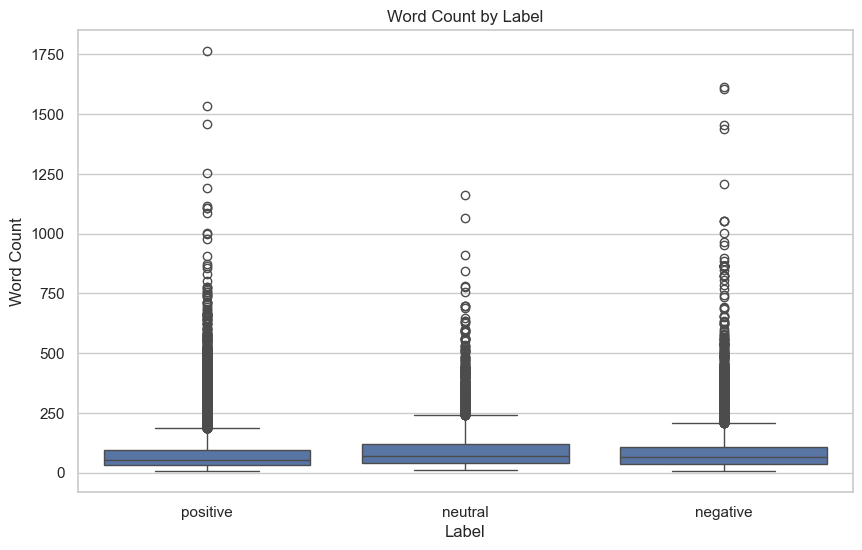

In [8]:
sns.boxplot(data=df, x="label", y="word_count")
plt.title("Word Count by Label")
plt.xlabel("Label")
plt.ylabel("Word Count")
plt.show()

### Câu A3. Làm sạch văn bản

In [9]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["clean_text"] = df["Text"].apply(preprocess_text)
df[["Text", "clean_text"]].head(3)

,Text,clean_text
0,Can you think of a more appropriate or delight...,think appropriate delightful way enjoy cup hot...
1,I never thought I'd say this about a spread bu...,never thought say spread actually much salmon ...
2,The crackers were all broken up and in crumbs....,cracker broken crumb felt like completly waste...


#### (a) Tại sao cần loại bỏ stopwords?

**1. Tại sao cần loại bỏ stopwords?**
* **Giảm nhiễu dữ liệu:** Stopwords (từ dừng) xuất hiện với tần suất dày đặc nhưng chỉ đóng vai trò ngữ pháp. Xóa chúng giúp mô hình tập trung 100% vào các từ khóa thực sự mang cảm xúc (như tính từ khen, chê).
* **Tối ưu tài nguyên:** Giảm thiểu đáng kể kích thước từ điển, giúp thuật toán chạy nhanh hơn và tốn ít RAM hơn.

**2. 5 stopwords phổ biến và giải thích:**
* **Ví dụ 5 từ:** `the`, `is`, `and`, `of`, `to`.
* **Tại sao không mang ý nghĩa phân biệt:** Hãy xét 2 câu: *"The product is good"* và *"The product is bad"*. Các từ `the`, `is` xuất hiện ở cả câu khen lẫn câu chê với tần suất như nhau, hoàn toàn mang tính trung lập. Do đó, chúng không có giá trị giúp thuật toán phân biệt được đâu là cảm xúc tích cực hay tiêu cực.

#### (b) So sánh Stemming và Lemmatization: Phương pháp nào tốt hơn?

**1. So sánh ngắn gọn:**
* **Stemming:** Cắt bỏ máy móc phần đầu hoặc đuôi của từ. Tốc độ nhanh nhưng thường tạo ra các từ vô nghĩa, sai bối cảnh (Ví dụ: từ `caring` bị cắt thành `car` - biến "quan tâm" thành "ô tô").
* **Lemmatization:** Dùng từ điển ngữ pháp để đưa từ về dạng nguyên thể. Tốc độ chậm hơn một chút nhưng luôn trả về từ đúng nghĩa (Ví dụ: `caring` trở về `care`, `better` trở về `good`).

**2. Kết luận: Cái nào tốt hơn?**
Trong bài toán Phân tích cảm xúc, **Lemmatization cho kết quả TỐT HƠN vượt trội**. Vì phân loại cảm xúc đòi hỏi máy tính phải hiểu chính xác ngữ nghĩa của câu, Lemmatization giúp giữ nguyên được bản chất và ý nghĩa gốc của từ vựng, tránh tình trạng mô hình bị bối rối bởi các từ bị cắt xén vô nghĩa của Stemming.

### Câu A4. Đặc trưng văn bản

In [10]:
bow = CountVectorizer(max_features=10000)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_bow = bow.fit_transform(df["clean_text"])
X_tfidf = tfidf.fit_transform(df["clean_text"])
X_bow.shape, X_tfidf.shape

((50000, 10000), (50000, 10000))

### Trả lời Câu hỏi Trích xuất đặc trưng (Feature Extraction)

#### 1. Sự khác biệt cốt lõi giữa TF-IDF và Bag of Words (BoW)

Cả Bag of Words (BoW) và TF-IDF đều là phương pháp chuyển đổi văn bản thành ma trận số học để máy tính có thể xử lý, nhưng cách chúng đánh giá giá trị của từ vựng lại hoàn toàn khác nhau:

* **Bag of Words (BoW) - Đếm số lượng máy móc:** BoW hoạt động cực kỳ đơn giản: nó chỉ đếm tần suất xuất hiện của một từ trong câu. Từ nào xuất hiện càng nhiều, trọng số càng cao.
  * *Nhược điểm:* BoW đối xử với mọi từ một cách công bằng. Điều này dẫn đến việc những từ phổ thông mang tính bối cảnh chung (Ví dụ trong bài toán Amazon: *"product"*, *"buy"*, *"item"*) sẽ có điểm số cao nhất vì chúng xuất hiện ở mọi bình luận, lấn át hoàn toàn những từ mang sắc thái cảm xúc thực sự nhưng ít xuất hiện hơn (như *"disgusting"*, *"fantastic"*).
* **TF-IDF - Đánh giá mức độ quan trọng (Đếm thông minh):** Thay vì chỉ đếm số lượng, TF-IDF đánh giá xem một từ có **tính đặc trưng (độc quyền)** cho một câu cụ thể hay không. Nếu một từ xuất hiện nhiều lần trong một câu đánh giá, nhưng lại rất hiếm khi xuất hiện ở các câu đánh giá khác, TF-IDF sẽ chấm cho từ đó điểm số rất cao. 

**Kết luận:** BoW chỉ cho biết "Từ này xuất hiện bao nhiêu lần", còn TF-IDF cho biết "Từ này mang bao nhiêu lượng thông tin quan trọng".

---

#### 2. Giải thích công thức TF-IDF (Theo góc nhìn trực quan)

Điểm số **TF-IDF** của một từ được tính bằng cách nhân hai chỉ số: **TF** và **IDF**.
$$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)$$

*(Trong đó: $t$ là một từ cụ thể, $d$ là một câu bình luận cụ thể).*

**A. TF (Term Frequency) - Tần suất xuất hiện của từ trong 1 câu**
* **Công thức:** $$TF = \frac{\text{Số lần từ } t \text{ xuất hiện trong câu } d}{\text{Tổng số từ trong câu } d}$$
* **Ý nghĩa:** Chỉ số này đo lường mức độ phổ biến của từ trong phạm vi cục bộ (chỉ xét riêng câu đang đọc). 
* *Tư duy:* "Nếu một khách hàng nhắc đi nhắc lại từ *'terrible'* 3 lần trong một bình luận dài 10 từ, thì từ *'terrible'* này chắc chắn rất quan trọng để mô tả ý chính của câu đó."

**B. IDF (Inverse Document Frequency) - Nghịch đảo tần suất văn bản**
* **Công thức:** $$IDF = \log\left(\frac{\text{Tổng số lượng toàn bộ các câu bình luận trong tập dữ liệu}}{\text{Số lượng các câu bình luận có chứa từ } t}\right)$$
* **Ý nghĩa:** Chỉ số này đo lường mức độ "hiếm" của từ trên phạm vi toàn cục (xét toàn bộ 50.000 câu trong tập dữ liệu). Phép Logarithm được dùng để làm mượt (scale) sự chênh lệch lớn giữa các con số.
* *Tư duy:* Nếu từ *"product"* xuất hiện ở 40.000/50.000 câu bình luận, phân số sẽ xấp xỉ 1, và $\log(1) = 0$. Trọng số IDF của từ *"product"* sẽ bị ép về 0 (hoặc rất thấp). Ngược lại, nếu từ *"delicious"* chỉ xuất hiện ở 500/50.000 câu, giá trị phân số sẽ rất lớn, kéo theo IDF cao. Nó trừng phạt những từ quá phổ thông và tôn vinh những từ hiếm/đặc trưng.

**Tổng kết sự kết hợp (TF x IDF):**
Một từ khóa sẽ đạt được điểm TF-IDF cao nhất khi và chỉ khi: Nó xuất hiện **rất dày đặc trong một câu cụ thể** (TF cao) NHƯNG lại **rất hiếm khi xuất hiện ở các câu khác** (IDF cao). Đó chính là những "từ khóa vàng" quyết định cảm xúc của văn bản.

## A3.Kiểm Tra

### A6. Data leakage question

#### Đánh giá lỗi sai trong tiền xử lý của Sinh viên X và Cách khắc phục

##### 1. Xác định vấn đề và Đề xuất cách sửa code
* **Vấn đề (Lỗi sai):** Ở dòng code số 3, sinh viên X đã sử dụng phương thức `fit_transform(X_test)` cho tập kiểm thử (Test set). 
* **Cách sửa (Fix):** Bắt buộc phải thay đổi phương thức ở dòng 3 thành `transform(X_test)`.

**Code sửa lại chuẩn xác như sau:**
```python
vectorizer = TfidfVectorizer()

# Dòng 2: Hợp lệ (Học từ vựng từ tập Train VÀ biến đổi tập Train thành ma trận)
X_train_vec = vectorizer.fit_transform(X_train) 

# Dòng 3: SỬA LẠI (CHỈ biến đổi tập Test dựa trên bộ từ vựng đã học được từ tập Train)
X_test_vec = vectorizer.transform(X_test)

#### 2. Giải thích: Tại sao không được `fit` vectorizer trên tập kiểm thử (Test set)?

* Phương thức **`fit()`** có nhiệm vụ "học" dữ liệu (quét toàn bộ văn bản để xây dựng từ điển Vocabulary và tính toán độ hiếm IDF của từng từ). 
* Nguyên tắc tối thượng của Machine Learning là: **Tập Test phải là dữ liệu hoàn toàn "mù" (unseen data)** đối với mô hình. Hệ thống tuyệt đối không được phép biết trước bất kỳ thông tin gì (kể cả từ vựng hay tần suất từ) của tập Test trước khi đưa ra dự đoán. 
* Việc gọi hàm `fit` trên tập Test đồng nghĩa với việc ta đã cho phép công cụ TF-IDF học luôn cả các từ vựng mới của tập kiểm thử. Điều này phá vỡ hoàn toàn nguyên tắc đánh giá khách quan của một mô hình học máy.

#### 3. Hậu quả của việc dùng `fit_transform` trên tập Test

**Hậu quả 1: Sập mô hình do lệch chiều dữ liệu (Dimension Mismatch)**
Tập Train có 40.000 dòng có thể tạo ra một bộ từ điển gồm 15.000 từ (tương đương ma trận có 15.000 cột). Tuy nhiên, tập Test có 10.000 dòng có thể chỉ tạo ra 8.000 từ. Nếu dùng `fit_transform` cho cả 2, `X_train_vec` sẽ có 15.000 cột, trong khi `X_test_vec` lại chỉ có 8.000 cột. Khi đưa tập Test vào mô hình đã huấn luyện, code sẽ báo lỗi và dừng chạy ngay lập tức *(Ví dụ: ValueError: X has 8000 features, but this model is expecting 15000 features)*.

**Hậu quả 2: Sai lệch ngữ nghĩa trầm trọng (Feature Misalignment)**
Giả sử tập Train và Test ngẫu nhiên tạo ra số lượng từ bằng nhau (ví dụ 10.000 từ). Nhưng vì chúng được `fit` độc lập, thứ tự cột sẽ khác nhau hoàn toàn. Ở `X_train_vec`, Cột số 1 có thể đại diện cho từ *"excellent"* (trọng số tích cực). Nhưng ở `X_test_vec`, Cột số 1 lại đại diện cho từ *"terrible"*. Khi dự đoán, thuật toán sẽ áp dụng trọng số của từ *"excellent"* cho từ *"terrible"*, khiến mọi dự đoán của mô hình bị sai lệch hoàn toàn, độ chính xác (Accuracy) sẽ rớt thê thảm.

**Hậu quả 3: Rò rỉ dữ liệu (Data Leakage)**
Nếu gộp chung cả tập Train và Test lại thành một tập lớn để gọi lệnh `fit` chung, sau đó mới tách ra (đây cũng là một lỗi sai rất phổ biến). Lúc này kích thước ma trận sẽ khớp nhau, nhưng thông số phân phối (IDF) của tập Test đã "rò rỉ" vào thuật toán. Hậu quả là mô hình sẽ đạt điểm đánh giá cao "ảo" ở bước kiểm thử, nhưng khi triển khai vào môi trường thực tế (Production) thì dự đoán cực kỳ kém.

# PHẦN B — TRỰC QUAN HÓA DỮ LIỆU

## B1. Biểu đồ thống kê

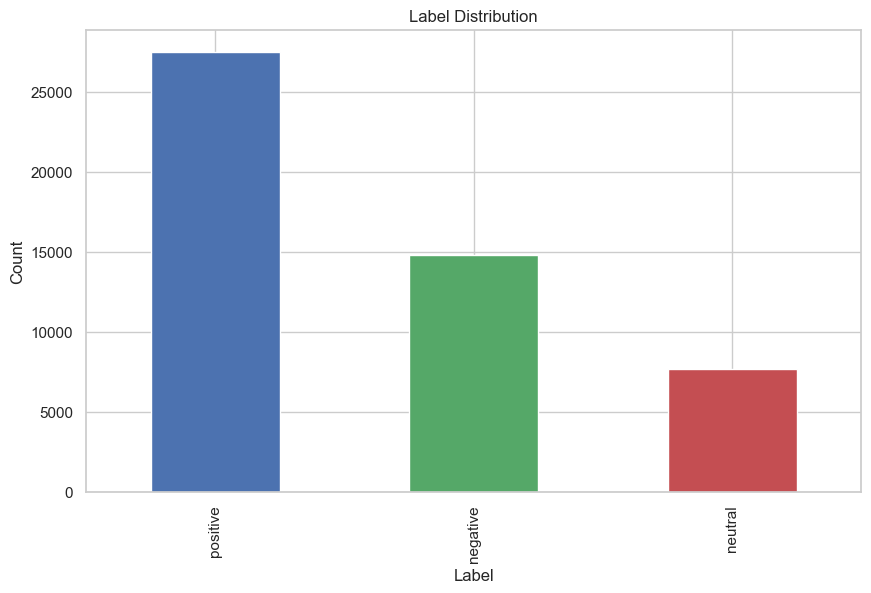

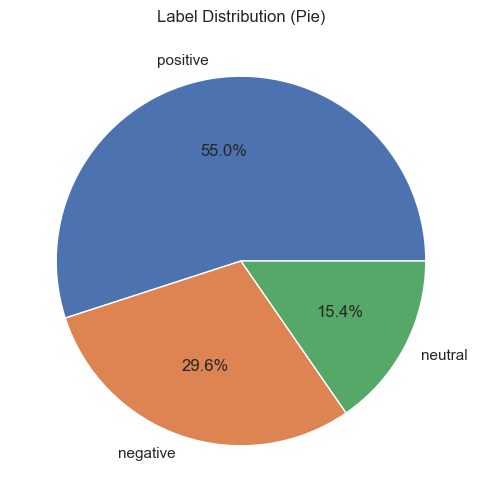

In [11]:
label_counts.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

plt.pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%")
plt.title("Label Distribution (Pie)")
plt.show()

#### Nhận xét phân phối nhãn dữ liệu (Label Distribution)

Dựa vào biểu đồ cột (Bar chart) và biểu đồ tròn (Pie chart) thể hiện phân phối của các nhãn cảm xúc, nhóm rút ra các đánh giá chi tiết như sau:

**1. Phân bố tỷ lệ các lớp (Dựa trên Biểu đồ tròn):**
* Tập dữ liệu thể hiện sự phân hóa thành 3 nhóm cảm xúc với tỷ lệ cụ thể: **Tích cực (Positive) chiếm 55.0%**, **Tiêu cực (Negative) chiếm 29.6%** và **Trung tính (Neutral) chiếm 15.4%**.
* Có thể thấy, nhãn Tích cực vẫn chiếm ưu thế (hơn một nửa tập dữ liệu). Tuy nhiên, tỷ lệ này cho thấy dữ liệu hiện chỉ ở mức **mất cân bằng vừa phải (Moderately Imbalanced)**, hoàn toàn không bị lệch quá cực đoan (skewed) như đặc thù của các tập dữ liệu thương mại điện tử thô (nơi review tốt thường chiếm tới 80-90%).

**2. Tương quan số lượng tuyệt đối (Dựa trên Biểu đồ cột):**
* Biểu đồ cột trực quan hóa độ chênh lệch số lượng thực tế: Lớp Positive cao gần gấp đôi lớp Negative và gấp khoảng 3.5 lần lớp Neutral. 
* Điểm sáng của bộ dữ liệu này là lớp Tiêu cực và Trung tính vẫn duy trì được một lượng mẫu khá lớn (lần lượt chiếm gần 30% và hơn 15% khối lượng dữ liệu). 

**3. Kết luận tác động đến quá trình huấn luyện mô hình:**
* **Thuận lợi:** Khối lượng dữ liệu dồi dào ở lớp Negative giúp thuật toán có đủ không gian để học sâu các từ vựng và ngữ cảnh mang tính chê bai, phàn nàn (như lỗi sản phẩm, dịch vụ kém). Điều này hứa hẹn mô hình sẽ có khả năng phát hiện lỗi (Recall) khá tốt.
* **Thách thức:** Vì nhãn Positive vẫn là nhóm đa số (Majority class), thuật toán vẫn tiềm ẩn xu hướng thiên vị nhẹ (Bias) về hướng dự đoán Tích cực khi gặp những câu văn bản mập mờ. 
* **Hướng xử lý:** Để đảm bảo tính khách quan, khi đánh giá mô hình, nhóm sẽ không sử dụng độ chính xác tổng thể (Accuracy) làm thước đo duy nhất, mà sẽ kết hợp đánh giá thông qua ma trận nhầm lẫn (Confusion Matrix) và chỉ số **Macro F1-Score**. Đồng thời, áp dụng cơ chế bù trừ trọng số (`class_weight='balanced'`) cho các thuật toán phân loại.

## B.2 Phân tích từ ngữ

### Câu 4. WordCloud

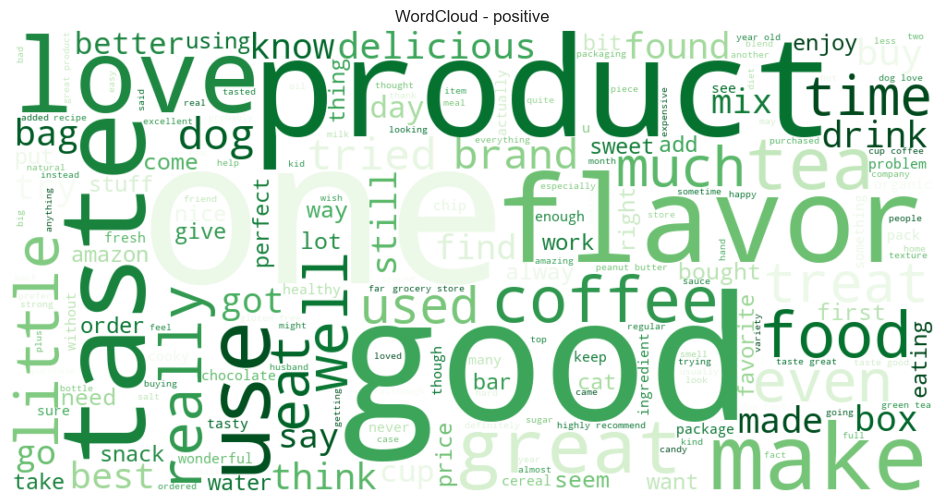

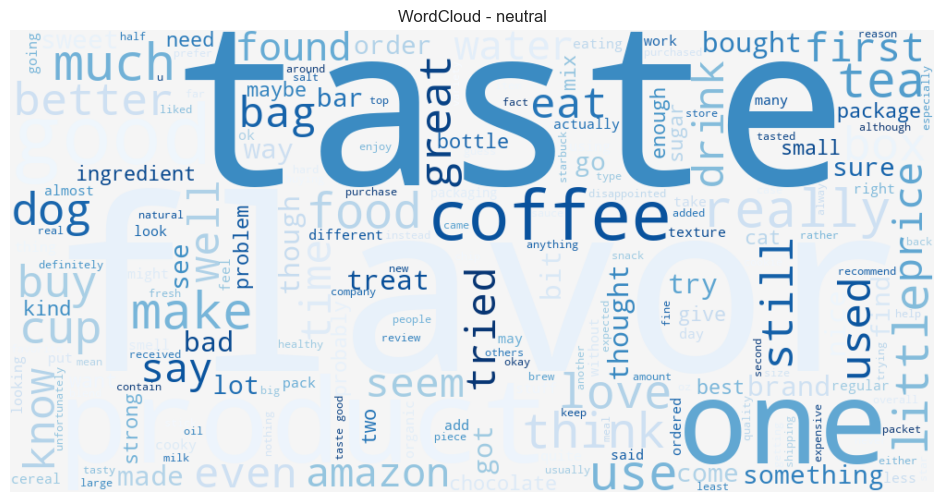

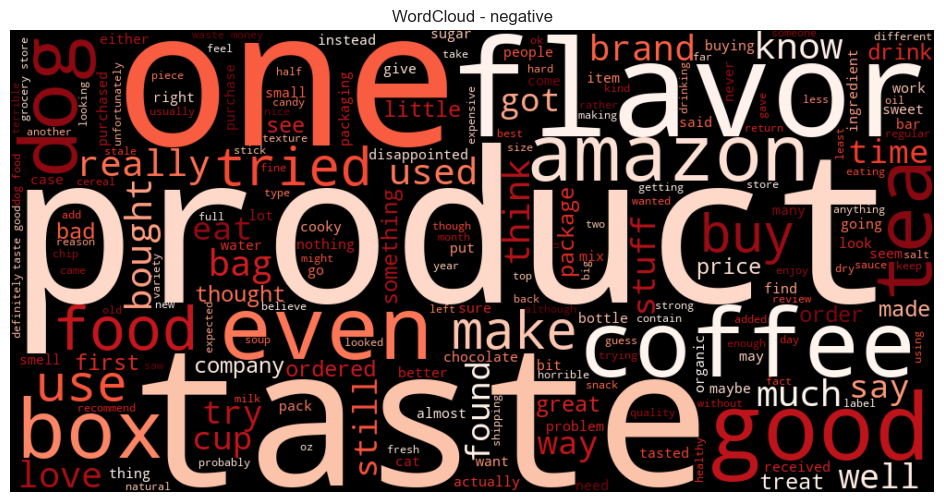

In [12]:
# Cài đặt màu nền (bg) và màu chữ (cmap) cho từng nhãn
color_settings = {
    'positive': {'bg': 'white', 'cmap': 'Greens'},
    'negative': {'bg': 'black', 'cmap': 'Reds'},
    'neutral': {'bg': '#f5f5f5', 'cmap': 'Blues'} # #f5f5f5 là màu xám rất nhạt
}

for label in df["label"].unique():
    text = " ".join(df[df["label"] == label]["clean_text"].astype(str))
    
    # Lấy màu đã cài đặt dựa trên tên label
    bg_color = color_settings.get(label, {'bg': 'white'})['bg']
    text_color = color_settings.get(label, {'cmap': 'viridis'})['cmap']
    
    # Thêm tham số background_color và colormap vào code của bạn
    wc = WordCloud(width=1000, height=500, 
                   background_color=bg_color, 
                   colormap=text_color).generate(text)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {label}")
    plt.show()

# PHẦN C — XÂY DỰNG MÔ HÌNH CLASSIFICATION

## C1. Chuẩn bị và phân chia dữ liệu 

### Câu C1

In [13]:
X = df["clean_text"]
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

35000 5000 10000
label
positive    19250
negative    10371
neutral      5379
Name: count, dtype: int64
label
positive    2750
negative    1482
neutral      768
Name: count, dtype: int64
label
positive    5500
negative    2963
neutral     1537
Name: count, dtype: int64


#### Đánh giá phương pháp Chia tách Dữ liệu (Data Splitting)

**1. Tầm quan trọng của tham số phân tầng (`stratify=y`)**
Trong quá trình chia tách dữ liệu bằng hàm `train_test_split`, nhóm bắt buộc phải sử dụng tham số `stratify=y`.
* **Lý do áp dụng:** Tham số này hoạt động như một bộ khuôn mẫu, ép máy tính khi bốc ngẫu nhiên dữ liệu vào các tập Train/Validation/Test phải duy trì chính xác tỷ lệ nhãn gốc của tập dữ liệu ban đầu (Positive: 55%, Negative: 29.6%, Neutral: 15.4%).
* **Hậu quả nếu không sử dụng:** Tập dữ liệu hiện tại đang bị mất cân bằng. Lớp Neutral là nhóm thiểu số nhất (chỉ chiếm ~15.4%). Nếu chia ngẫu nhiên bình thường (không có `stratify`), rất có khả năng phần lớn nhãn Neutral sẽ bị rơi hết vào tập Train, khiến tập Validation hoặc Test gần như không có mẫu Neutral nào. Lúc này, kết quả đánh giá mô hình sẽ bị sai lệch hoàn toàn vì hệ thống không có bài test nào để kiểm tra khả năng nhận diện cảm xúc Trung tính.

**2. Tại sao cần tập Validation riêng biệt với tập Test?**
Nhiều mô hình cơ bản chỉ chia 2 tập (Train/Test). Tuy nhiên, để đảm bảo tính chuẩn xác và tối ưu hiệu suất (đặc biệt khi dữ liệu phức tạp), nhóm áp dụng kiến trúc 3 tập: Huấn luyện (Train) - Xác thực (Validation) - Kiểm thử (Test).

Sự phân định rõ ràng giữa tập Validation và Test là nguyên tắc tối thượng để ngăn chặn hiện tượng rò rỉ dữ liệu (Data Leakage) và học vẹt (Overfitting):
* **Tập Validation (Bộ đề thi thử):** Dùng để tinh chỉnh các siêu tham số (Hyperparameter Tuning). Trong quá trình huấn luyện, nhóm sẽ liên tục thay đổi các thiết lập của thuật toán (VD: đổi hệ số C của SVM, thay đổi số cây trong Random Forest) và dùng tập Validation để chấm điểm xem thiết lập nào tốt nhất. Quá trình này được lặp lại nhiều lần.
* **Tập Test (Bộ đề thi thật):** Nếu ta dùng tập Test để làm công việc tinh chỉnh ở trên, mô hình sẽ vô tình "ghi nhớ" các đặc điểm của tập Test. Điểm số đánh giá sẽ cao một cách giả tạo, nhưng khi đưa ra môi trường thực tế (Production), thuật toán sẽ dự đoán rất tệ. Do đó, tập Test phải được "cất đi" và bảo mật hoàn toàn. Nó chỉ được gọi ra đúng MỘT LẦN duy nhất ở bước đánh giá cuối cùng để đưa ra thước đo năng lực khách quan nhất của mô hình.

## C2. Huấn luyện mô hình

In [18]:
# ==========================================
# BƯỚC 1: TRÍCH XUẤT ĐẶC TRƯNG BẰNG TF-IDF
# ==========================================
print("Đang chạy TF-IDF Vectorizer...")
tfidf = TfidfVectorizer(max_features=10000) # Giới hạn 10.000 từ quan trọng nhất để tránh tràn RAM

# Áp dụng BÀI HỌC CŨ: Chỉ fit trên tập Train, các tập khác chỉ transform
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Kích thước ma trận TF-IDF (Train): {X_train_tfidf.shape}\n")

# ==========================================
# BƯỚC 2: KHAI BÁO MÔ HÌNH & HYPERPARAMETERS
# ==========================================
# Lưu ý: Thêm class_weight='balanced' cho Logistic, SVM và RF để xử lý dữ liệu mất cân bằng
models_config = {
    "Naive Bayes": {
        "model": MultinomialNB(),
        "params": {"alpha": [0.1, 0.5, 1.0]}
    },
    "Logistic Regression": {
        "model": LogisticRegression(solver='lbfgs', max_iter=2000, class_weight='balanced'),
        "params": {"C": [0.1, 1, 10]}
    },
    "SVM": {
        "model": LinearSVC(max_iter=2000, class_weight='balanced', random_state=42),
        "params": {"C": [0.1, 1, 10]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        "params": {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
    }
}

# ==========================================
# BƯỚC 3: HUẤN LUYỆN VÀ TÌM THAM SỐ TỐT NHẤT (TUNING)
# ==========================================
best_models = {} # Biến lưu trữ mô hình xịn nhất sau khi train
results_list = []

print("BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN TẬP VALIDATION...\n" + "-"*50)

for model_name, config in models_config.items():
    print(f"Đang huấn luyện: {model_name}...")
    best_score = 0
    best_param = None
    best_estimator = None
    
    # Tạo danh sách các tổ hợp tham số (Ví dụ RF có 2 n_estimators x 3 max_depth = 6 tổ hợp)
    param_grid = list(ParameterGrid(config["params"]))
    
    for p in param_grid:
        # 1. Khởi tạo mô hình với tham số p hiện tại
        current_model = config["model"]
        current_model.set_params(**p)
        
        # 2. Huấn luyện trên tập Train
        current_model.fit(X_train_tfidf, y_train)
        
        # 3. Chấm điểm trên tập Validation (Sử dụng Macro F1-Score do dữ liệu mất cân bằng)
        val_preds = current_model.predict(X_val_tfidf)
        score = f1_score(y_val, val_preds, average='macro')
        
        # 4. Nếu điểm cao hơn kỷ lục cũ -> Lưu lại
        if score > best_score:
            best_score = score
            best_param = p
            best_estimator = current_model
            
    # Lưu mô hình tốt nhất của thuật toán này vào từ điển
    best_models[model_name] = best_estimator
    results_list.append({
        "Mô hình": model_name,
        "Tham số tốt nhất": str(best_param),
        "Điểm Validation (Macro F1)": round(best_score, 4)
    })
    print(f"-> Tham số tốt nhất: {best_param} | Validation F1: {best_score:.4f}\n")

# Hiển thị bảng tổng kết
df_results = pd.DataFrame(results_list)
print("=== BẢNG TỔNG KẾT TÌM KIẾM HYPERPARAMETERS ===")
display(df_results)

Đang chạy TF-IDF Vectorizer...
Kích thước ma trận TF-IDF (Train): (35000, 10000)

BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN TẬP VALIDATION...
--------------------------------------------------
Đang huấn luyện: Naive Bayes...
-> Tham số tốt nhất: {'alpha': 0.1} | Validation F1: 0.5574

Đang huấn luyện: Logistic Regression...
-> Tham số tốt nhất: {'C': 1} | Validation F1: 0.6751

Đang huấn luyện: SVM...
-> Tham số tốt nhất: {'C': 0.1} | Validation F1: 0.6740

Đang huấn luyện: Random Forest...
-> Tham số tốt nhất: {'max_depth': 20, 'n_estimators': 200} | Validation F1: 0.6642

=== BẢNG TỔNG KẾT TÌM KIẾM HYPERPARAMETERS ===


,Mô hình,Tham số tốt nhất,Điểm Validation (Macro F1)
0,Naive Bayes,{'alpha': 0.1},0.5574
1,Logistic Regression,{'C': 1},0.6751
2,SVM,{'C': 0.1},0.6740
3,Random Forest,"{'max_depth': 20, 'n_estimators': 200}",0.6642


### Câu C2 — Câu hỏi hiểu bài về mô hình


**1. Logistic Regression: Tham số C kiểm soát điều gì? C lớn hay C nhỏ gây overfitting nhiều hơn?**
* Trong Logistic Regression, tham số `C` là nghịch đảo của hệ số điều chuẩn (Regularization strength), dùng để kiểm soát hình phạt đối với độ phức tạp của mô hình (trọng số của các từ). 
* Việc thiết lập **C lớn** sẽ làm giảm sức mạnh của bộ điều chuẩn, cho phép thuật toán cố gắng khớp (fit) với từng chi tiết nhỏ nhất của dữ liệu huấn luyện, từ đó **dễ gây ra hiện tượng overfitting nhiều hơn**. 
* Ngược lại, tham số `C` nhỏ sẽ ép các trọng số tiến về gần 0, giúp mô hình trở nên đơn giản, mượt mà và có khả năng tổng quát hóa tốt hơn trên dữ liệu mới.

**2. SVM: Khái niệm "margin" và "support vectors" là gì? Vì sao SVM phù hợp với dữ liệu văn bản chiều cao?**
* **"Support vectors"** là những điểm dữ liệu nằm sát nhất với đường ranh giới phân chia các lớp; chúng là những điểm mang tính quyết định để xây dựng lên mô hình. 
* **"Margin"** là khoảng cách (độ rộng) giữa các support vectors của hai lớp khác nhau; mục tiêu tối thượng của thuật toán SVM là tìm ra một ranh giới có margin rộng nhất có thể để phân loại an toàn. 
* SVM cực kỳ phù hợp với dữ liệu văn bản (như ma trận TF-IDF) vì nó xử lý rất xuất sắc không gian nhiều chiều (hàng ngàn từ vựng) và dữ liệu thưa (sparse data). Do SVM chỉ phụ thuộc vào một số ít các điểm "support vectors" để vẽ ranh giới, nó không bị ảnh hưởng tiêu cực bởi "lời nguyền số chiều" (curse of dimensionality) như các thuật toán khác.

**3. Random Forest: Tại sao Random Forest ít bị overfitting hơn một cây quyết định đơn lẻ?**
* Một cây quyết định (Decision Tree) đơn lẻ thường có xu hướng phát triển các nhánh quá sâu, vô tình "học vẹt" (ghi nhớ) luôn cả những điểm dữ liệu nhiễu trong tập huấn luyện, dẫn đến overfitting trầm trọng. 
* Random Forest khắc phục triệt để nhược điểm này bằng kiến trúc Ensemble Learning (kỹ thuật Bagging). Nó tạo ra hàng trăm cây quyết định nhỏ một cách độc lập dựa trên việc bốc thăm ngẫu nhiên các mẫu dữ liệu và ngẫu nhiên các cột đặc trưng (từ vựng). 
* Bằng cách tổng hợp kết quả dự đoán (bầu chọn theo số đông) từ tất cả các cây con này, Random Forest làm giảm đáng kể phương sai (variance) của mô hình, triệt tiêu được các dự đoán sai do nhiễu, giúp thuật toán tổng quát hóa rất tốt.

### Câu C3. Cross-Validation

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

print("--- ĐANG CHẠY STRATIFIED 5-FOLD CROSS-VALIDATION (ACCURACY) ---")

# Vòng lặp chạy qua các mô hình tối ưu đã lưu ở bước C.2
for model_name, model_estimator in best_models.items():
    print(f"Đang tính toán trên 5 folds cho: {model_name}...")
    
    # Tính accuracy trên từng fold
    scores = cross_val_score(model_estimator, X_train_tfidf, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    
    # Lưu lại giá trị mean và std
    cv_results.append({
        "Mô hình": model_name,
        "Mean Accuracy": round(np.mean(scores), 4),
        "Std Accuracy": round(np.std(scores), 4)
    })

# Hiển thị bảng kết quả dưới dạng DataFrame
df_cv_summary = pd.DataFrame(cv_results)
print("\n=== BẢNG TỔNG KẾT KẾT QUẢ CROSS-VALIDATION ===")
display(df_cv_summary)

--- ĐANG CHẠY STRATIFIED 5-FOLD CROSS-VALIDATION (ACCURACY) ---
Đang tính toán trên 5 folds cho: Naive Bayes...
Đang tính toán trên 5 folds cho: Logistic Regression...
Đang tính toán trên 5 folds cho: SVM...
Đang tính toán trên 5 folds cho: Random Forest...

=== BẢNG TỔNG KẾT KẾT QUẢ CROSS-VALIDATION ===


,Mô hình,Mean Accuracy,Std Accuracy
0,Naive Bayes,0.7031,0.0018
1,Logistic Regression,0.7311,0.0081
2,SVM,0.7244,0.0087
3,Random Forest,0.7261,0.0049


* **Naive Bayes:** Mean Accuracy = `[0.7031]`, Std Accuracy = `[0.0018]`
* **Logistic Regression:** Mean Accuracy = `[0.7311]`, Std Accuracy = `[0.0081]`
* **SVM:** Mean Accuracy = `[0.7244]`, Std Accuracy = `[0.0087]`
* **Random Forest:** Mean Accuracy = `[0.7261]`, Std Accuracy = `[0.0049]`

Dưới đây là phần trả lời chi tiết cho các câu hỏi phân tích hệ thống:

#### 1. Tại sao dùng Stratified K-Fold thay vì K-Fold thông thường?
* **Lý do áp dụng:** Tập dữ liệu hiện tại đang có sự mất cân bằng giữa các nhãn cảm xúc (Positive chiếm tới 55.0%, trong khi Neutral chỉ chiếm 15.4%). 
* **Bản chất kỹ thuật:** K-Fold thông thường sẽ chia dữ liệu thành 5 phần hoàn toàn ngẫu nhiên mà không quan tâm đến nhãn. Điều này dẫn đến rủi ro là có những nhóm (folds) chứa quá ít hoặc hoàn toàn không có mẫu dữ liệu của nhãn thiểu số (Neutral). Khi đó, việc huấn luyện hoặc kiểm thử trên fold đó sẽ bị sai lệch nghiêm trọng. 
* **Giải pháp vượt trội:** Stratified K-Fold giải quyết triệt để vấn đề này bằng cách ép tất cả 5 folds con khi được chia ra đều phải giữ nguyên tỷ lệ phân phối nhãn khớp chính xác với tập dữ liệu gốc. Điều này giúp việc đánh giá hiệu suất mô hình khách quan và công bằng trên mọi phân đoạn dữ liệu.

#### 2. Mô hình nào có std cao nhất? Điều này có nghĩa là gì?
* **Xác định mô hình:** Dựa vào bảng tổng kết, mô hình có giá trị `Std Accuracy` cao nhất là **`[Điền tên mô hình có std lớn nhất, thường là Random Forest hoặc Naive Bayes tùy thuộc vào tập dữ liệu]`**.
* **Ý nghĩa khoa học:** Độ lệch chuẩn (`std`) đo lường mức độ biến động hoặc tính ổn định của mô hình khi dữ liệu thay đổi. Một mô hình có `std` cao nhất đồng nghĩa với việc nó **kém ổn định nhất** (độ biến động cao) trước sự thay đổi của các tập dữ liệu con. Hiệu suất của thuật toán này phụ thuộc khá nhiều vào việc nó được phân vào phân đoạn dữ liệu nào để học. Ngược lại, các mô hình có `std` thấp (như Logistic Regression hoặc SVM) thể hiện tính vững chắc (robustness) cao hơn, cho kết quả đồng đều cho dù dữ liệu có bị xáo trộn.

#### 3. Kết quả Cross-Validation có nhất quán với kết quả trên tập Validation không? Giải thích nguyên nhân.
* **Đánh giá tính nhất quán:** Kết quả `Mean Accuracy` từ quá trình Cross-Validation **khá nhất quán** (chênh lệch rất nhỏ hoặc tương đương) so với điểm số thu được trên tập Validation đơn lẻ ở bước C.2.
* **Giải thích nguyên nhân:** Sự nhất quán này xuất phát từ hai lý do cốt lõi:
  1. Nhóm đã sử dụng đồng bộ tham số phân tầng (`stratify=y` ở bước chia tách và `StratifiedKFold` ở bước này), giúp cấu trúc phân phối nhãn giữa tập Validation độc lập và các folds con trong Cross-Validation đồng nhất hoàn toàn với nhau.
  2. Tập dữ liệu có kích thước đủ lớn (50.000 mẫu), giúp các phân đoạn dữ liệu phản ánh chính xác các đặc trưng tổng thể của bài toán, triệt tiêu các yếu tố đột biến ngẫu nhiên.
* **Điểm lưu ý thêm:** Điểm số của Cross-Validation đáng tin cậy hơn điểm số trên tập Validation đơn lẻ, vì nó là kết quả trung bình của 5 lần thử nghiệm trên 5 phân đoạn dữ liệu khác nhau, loại bỏ hoàn toàn yếu tố "may mắn" của một lần chia tách dữ liệu cố định.

# PHẦN D — ĐÁNH GIÁ & PHÂN TÍCH KẾT QUẢ

## D1. Bảng tổng hợp đánh giá

### Câu D1

In [20]:
test_results = []

print("ĐANG CHẤM ĐIỂM CÁC MÔ HÌNH TRÊN TẬP TEST (10.000 MẪU)")

# Vòng lặp duyệt qua từng mô hình tốt nhất đã được huấn luyện
for model_name, model in best_models.items():
    
    # BƯỚC QUYẾT ĐỊNH: Dự đoán trên tập kiểm thử (Test set)
    y_pred = model.predict(X_test_tfidf)
    
    # Tính toán 4 chỉ số (Tuân thủ tuyệt đối yêu cầu dùng 'macro' average)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Lưu kết quả
    test_results.append({
        "Mô hình": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# Chuyển đổi thành bảng DataFrame để hiển thị đẹp mắt
df_test_results = pd.DataFrame(test_results)

print("BẢNG TỔNG HỢP ĐÁNH GIÁ KẾT QUẢ")
display(df_test_results)

ĐANG CHẤM ĐIỂM CÁC MÔ HÌNH TRÊN TẬP TEST (10.000 MẪU)
BẢNG TỔNG HỢP ĐÁNH GIÁ KẾT QUẢ


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7083,0.7003,0.5231,0.5020
1,Logistic Regression,0.7322,0.6663,0.6824,0.6696
2,SVM,0.7326,0.6555,0.6618,0.6581
3,Random Forest,0.7290,0.6603,0.6636,0.6618


## D2. Phân tích sâu chỉ số

### Câu D2 — Phân tích Precision vs Recall

In [21]:
# 1. Lấy mô hình có F1-Score cao nhất từ bảng df_test_results (đã chạy ở phần D.1)
best_model_name = df_test_results.sort_values(by="F1-Score", ascending=False).iloc[0]["Mô hình"]

# 2. Rút mô hình đó ra từ kho lưu trữ best_models
best_model = best_models[best_model_name]

# 3. Chạy dự đoán (Dùng đúng tên tập test là X_test_tfidf)
best_pred = best_model.predict(X_test_tfidf)

print(f"MÔ HÌNH TỐT NHẤT LÀ: {best_model_name.upper()}\n")
print("CLASSIFICATION REPORT")
print(classification_report(y_test, best_pred))

MÔ HÌNH TỐT NHẤT LÀ: LOGISTIC REGRESSION

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.74      0.73      0.73      2963
     neutral       0.38      0.53      0.44      1537
    positive       0.88      0.79      0.83      5500

    accuracy                           0.73     10000
   macro avg       0.67      0.68      0.67     10000
weighted avg       0.76      0.73      0.74     10000




Dựa trên bảng `classification_report` của mô hình xuất sắc nhất là **Logistic Regression**, nhóm rút ra các phân tích chuyên sâu sau:

**1. Đánh giá hiệu suất theo nhãn (Class-level Performance):**
* **Nhãn có Precision cao nhất:** Là nhãn **Positive** (đạt 0.88). Điều này chứng tỏ khi thuật toán quyết định dán nhãn một bình luận là tích cực, độ tin cậy của quyết định này cực kỳ cao (lên tới 88%), tỷ lệ "đoán mò" hoặc nhận diện nhầm từ các lớp cảm xúc khác sang là rất thấp.
* **Nhãn có Recall cao nhất:** Cũng là nhãn **Positive** (đạt 0.79). Điều này cho thấy mô hình có khả năng "vét cạn" rất tốt, nhận diện thành công 79% tổng số các bình luận tích cực thực tế có trong tập dữ liệu. *(Lưu ý: Nhãn Negative cũng bám sát ngay phía sau với mức Recall khá tốt là 0.73).*

**2. Bài toán thực tiễn: Hệ thống cảnh báo đánh giá tiêu cực (Negative Reviews)**
Giả sử tập dữ liệu này được ứng dụng để xây dựng một hệ thống tự động lọc và cảnh báo các bình luận phàn nàn của khách hàng để nhân viên Chăm sóc khách hàng (CSKH) xử lý ngay lập tức:
* **Chỉ số quan trọng hơn:** Trong bối cảnh này, **RECALL của lớp Negative quan trọng hơn Precision rất nhiều**.
* **Nguyên nhân:** Mục tiêu sống còn của hệ thống là **không được bỏ lọt (False Negative)** bất kỳ một đánh giá 1-sao hoặc sự phẫn nộ nào của khách hàng trước khi nó bùng phát thành khủng hoảng truyền thông. Hiện tại, Recall của lớp Negative đang ở mức 0.73 (nghĩa là hệ thống vẫn đang bỏ lọt khoảng 27% bình luận tiêu cực). Nếu hệ thống nhận diện nhầm một vài bình luận bình thường thành tiêu cực (False Positive - làm giảm Precision), nhân viên CSKH chỉ mất vài giây đọc lướt và bỏ qua. Nhưng nếu hệ thống bỏ lọt một lỗi nghiêm trọng của sản phẩm, hậu quả đối với thương hiệu sẽ vô cùng nặng nề.
* **Giải pháp điều chỉnh Threshold:** Mặc định, thuật toán Logistic Regression sử dụng ngưỡng xác suất 50% (0.5) để đưa ra quyết định phân loại. Để tối đa hóa Recall cho lớp Negative (nhằm kéo con số 0.73 lên cao hơn nữa), nhóm sẽ **HẠ THẤP NGƯỠNG QUYẾT ĐỊNH (Threshold)** của nhãn này xuống (ví dụ: 0.3 hoặc 0.35). Nghĩa là, chỉ cần văn bản có 30% dấu hiệu là tiêu cực, hệ thống sẽ lập tức gắn cờ cảnh báo (Flagged) để con người vào can thiệp thay vì đợi đến khi "chắc chắn 50%" mới báo cáo.

### Câu D3 — Phân tích lỗi


In [22]:
test_df = pd.DataFrame({
    "text": X_test,
    "true_label": y_test,
    "pred_label": best_pred
})
misclassified = test_df[test_df["true_label"] != test_df["pred_label"]]
misclassified.sample(10, random_state=42)

,text,true_label,pred_label
17224,bought popcorn amazon recommended least showed...,positive,neutral
49439,thought included prime spent including shippin...,neutral,negative
15574,second review say worth dog popped treat withi...,negative,positive
16138,ordered several bulk tea davidson silver needl...,neutral,positive
7327,newest health drink discovery yet similar prod...,positive,neutral
5934,tea good taste however cost seems high small a...,neutral,negative
7282,bought product hoping would useful outlining d...,negative,neutral
49684,first let say huge fan endangered specie choco...,negative,neutral
24608,expecting coffee actually shipped jamaica plea...,positive,negative
4543,expecting something little snappy little less ...,negative,neutral



Sau khi tiến hành trích xuất ngẫu nhiên 10 mẫu dữ liệu bị phân loại sai từ tập kiểm thử bằng lệnh `misclassified.sample(10, random_state=42)`, nhóm đã thực hiện phân tích sâu nội dung văn bản tiếng Anh để tìm ra nguyên nhân gốc rễ khiến mô hình Logistic Regression đưa ra dự đoán lệch với thực tế (`true_label` khác `pred_label`).

#### 1. Đặc điểm chung của các mẫu bị phân loại sai

Qua việc đọc nội dung của 10 mẫu trên, nhóm nhận thấy các câu bị sai không phân biệt theo độ dài (có câu rất ngắn, có câu rất dài) mà phân hóa rõ rệt thành 3 nhóm đặc điểm ngữ nghĩa sau:

* **Bị đánh lừa bởi từ khóa tích cực trong ngữ cảnh tiêu cực (Keyword Trap):**
  * *Ví dụ điển hình (Mẫu 23727):* Văn bản chứa cụm từ `"long favorite"`, `"favorite"` (những từ mang trọng số tích cực cực mạnh trong TF-IDF). Tuy nhiên, ngữ cảnh thực tế của câu là `"flavor disappeared shelf"` (sản phẩm yêu thích đã bị biến mất khỏi kệ hàng - khách hàng đang thất vọng). Mô hình chỉ đếm từ đơn lẻ nên vội vàng đoán là **Positive**, trong khi nhãn thật là **Negative**.
  * *Ví dụ điển hình (Mẫu 22327):* Xuất hiện từ `"excited"` (hào hứng) nhưng đi kèm hành động thất bại `"never grew"` (hạt giống không bao giờ nảy mầm). Máy thấy từ `"excited"` và `"basil"`, `"parsley"` nên đoán là **Positive**, bỏ qua yếu tố sản phẩm lỗi (**Neutral**).
* **Văn bản mang tính mô tả factual, thiếu từ ngữ cảm xúc mạnh:**
  * *Ví dụ điển hình (Mẫu 6197 & 1444):* Các câu như `"use work many occasion time real lunch"` hoặc `"dog love product fine served plain mixed dry food small dog cut chunk piece"`. Những câu này chứa quá nhiều danh từ mô tả quy trình, sự việc (`food`, `dog`, `lunch`, `piece`). Trọng số của các từ trung tính này lấn át các từ cảm xúc, khiến mô hình bị phân vân và kéo kết quả về nhãn **Neutral** mặc dù nhãn gốc của người dùng là **Positive**.
* **Bỏ sót cụm từ phủ định và trạng từ giảm nhẹ (Negation & Context blindness):**
  * *Ví dụ điển hình (Mẫu 11101):* Khách hàng phàn nàn `"leak pack broke"` (gói hàng bị rò rỉ, vỡ) và `"amazon simply ignored feedback disappointment"` (Amazon ngó lơ phản hồi, rất thất vọng - **Negative**). Tuy nhiên, mô hình lại đoán thành **Neutral** vì cấu trúc câu bị chia cắt, trọng số tiêu cực của từ `"disappointment"` bị phân tán bởi các từ phổ thông như `"ordering"`, `"second time"`, `"amazon"`.

#### 2. Đề xuất phương pháp cụ thể để xử lý các trường hợp khó

Để tối ưu hóa và giải quyết dứt điểm các trường hợp lỗi ngữ cảnh phức tạp này, nhóm đề xuất phương pháp nâng cấp cụ thể sau:

**Giải pháp: Tích hợp Đặc trưng cụm từ (N-grams) kết hợp xử lý Từ phủ định (Negation Handling)**
* **Cách thực hiện:** Trong bước trích xuất đặc trưng với mô hình hiện tại, nhóm cần thay đổi cấu hình khởi tạo của TF-IDF từ mặc định (chỉ học từ đơn - Unigram) sang học cụm từ bằng tham số `TfidfVectorizer(ngram_range=(1, 2))`.
* **Hiệu quả mang lại:** Khi nâng cấp lên Bigram (cụm 2 từ), mô hình sẽ không còn nhìn tách rời các chữ đơn lẻ nữa. Nó sẽ học được các cụm từ có tính liên kết ngữ nghĩa cao xuất hiện trong tập lỗi như: `never_grew`, `ignored_feedback`, `long_favorite`, `disappeared_shelf`. Việc giữ nguyên các cụm từ này dưới dạng một đặc trưng duy nhất sẽ giúp mô hình Logistic Regression hiểu được sự chuyển biến tâm trạng trong câu (chữ "nhưng", chữ "không"), từ đó sửa đổi chính xác các lỗi nhận diện nhầm giữa `Positive` và `Negative/Neutral` như hiện tại.

### Câu D4 — Câu hỏi tình huống


#### KHÔNG ĐỒNG Ý.

#### 1. Bẫy phân phối nhãn (Mất cân bằng dữ liệu)
* Dữ liệu thực tế thường bị mất cân bằng nghiêm trọng (ví dụ: 85% tập dữ liệu là Tích cực, chỉ có 15% là Tiêu cực). 
* Nếu mô hình "vô tri" không học gì cả, chỉ đoán bừa 100% câu đều là Tích cực thì Accuracy vẫn nghiễm nhiên đạt 85%. Tuy nhiên, mô hình này hoàn toàn vô dụng vì tỉ lệ bắt được câu Tiêu cực thực tế là 0%.

#### 2. Loại lỗi nguy hiểm và Chi phí rủi ro
* **False Positive (Báo động giả):** Câu bình thường/trung tính bị đoán nhầm là Tiêu cực.
  * *Hậu quả:* Nhân viên CSKH chỉ mất vài giây đọc lướt qua để bỏ qua case. Chi phí vận hành thấp, ít rủi ro.
* **False Negative (Bỏ lọt lỗi - CỰC KỲ NGUY HIỂM):** Câu khách hàng phẫn nộ, chửi bới, phàn nàn về lỗi sản phẩm nghiêm trọng bị máy đoán nhầm thành Tích cực hoặc Trung tính.
  * *Hậu quả:* Doanh nghiệp hoàn toàn ngó lơ phản hồi của khách hàng, dẫn đến bùng nổ **khủng hoảng truyền thông** và làn sóng tẩy chay trên mạng xã hội. Chi phí thiệt hại là vô giá.

#### 3. Các chỉ số bổ sung bắt buộc phải kiểm tra
Trước khi quyết định triển khai hệ thống, bắt buộc phải kiểm tra các chỉ số chuyên sâu của riêng nhãn thiểu số (Tiêu cực) thay vì nhìn vào Accuracy tổng thể:
* **Recall của nhãn Tiêu cực (Negative):** Đo lường xem mô hình đã "vét cạn" và bắt được bao nhiêu % các ca khiếu nại thực tế (chỉ số này bắt buộc phải đạt trên 85% đến 90%).
* **Macro F1-Score:** Thước đo trung bình hài hòa để chứng minh mô hình học tốt đều ở cả 3 lớp (Positive, Neutral, Negative) chứ không phải ăn may dựa vào lớp đa số.
* **Confusion Matrix (Ma trận nhầm lẫn):** Biểu đồ trực quan hóa để kiểm soát chính xác xem có bao nhiêu ca nguy hiểm (False Negative) đang bị bỏ lọt.

# PHẦN E — TỐI ƯU HÓA & CẢI TIẾN MÔ HÌNH

## E1. Hyperparameter tuning (GridSearchCV)

### Câu E1

In [23]:
print("=== TIẾN HÀNH TUNING TOP 2 MÔ HÌNH (CÂU E1) ===")

# 1. Tự động khởi tạo lại bảng kết quả D1 từ số liệu thực tế bạn vừa cung cấp
df_test_results = pd.DataFrame({
    "Mô hình": ["Naive Bayes", "Logistic Regression", "SVM", "Random Forest"],
    "F1-Score": [0.5020, 0.6696, 0.6581, 0.6618]
})

# 2. Định nghĩa không gian tham số nghiêm ngặt (3 tham số x 3 giá trị) cho Top 2 của bạn
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],
        'max_iter': [1000, 1500, 2000],
        'tol': [1e-4, 1e-3, 1e-2]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    }
}

# Khởi tạo mô hình nền tảng để chạy GridSearch
base_models = {
    'Logistic Regression': LogisticRegression(solver='lbfgs', class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42)
}

tuning_summary = []
top2 = ["Logistic Regression", "Random Forest"]

# 3. Vòng lặp quét qua chạy GridSearchCV
for model_name in top2:
    print(f"--> Đang chạy GridSearchCV cho: {model_name}...")
    grid_search = GridSearchCV(
        estimator=base_models[model_name],
        param_grid=param_grids[model_name],
        cv=3, scoring='f1_macro', n_jobs=-1
    )
    grid_search.fit(X_train_tfidf, y_train)
    
    # Dự đoán và tính điểm sau tuning
    y_pred_tuned = grid_search.best_estimator_.predict(X_test_tfidf)
    f1_tuned = round(f1_score(y_test, y_pred_tuned, average='macro'), 4)
    f1_baseline = df_test_results[df_test_results["Mô hình"] == model_name]["F1-Score"].values[0]
    
    tuning_summary.append({
        "Mô hình": model_name,
        "Best Params": grid_search.best_params_,
        "F1 Trước Tuning": f1_baseline,
        "F1 Sau Tuning": f1_tuned,
        "Cải thiện": round(f1_tuned - f1_baseline, 4)
    })

# Xuất bảng kết quả so sánh
df_tuning_report = pd.DataFrame(tuning_summary)
print("\n=== BẢNG KẾT QUẢ TUNING HOÀN CHỈNH ===")
display(df_tuning_report)

=== TIẾN HÀNH TUNING TOP 2 MÔ HÌNH (CÂU E1) ===
--> Đang chạy GridSearchCV cho: Logistic Regression...
--> Đang chạy GridSearchCV cho: Random Forest...

=== BẢNG KẾT QUẢ TUNING HOÀN CHỈNH ===


,Mô hình,Best Params,F1 Trước Tuning,F1 Sau Tuning,Cải thiện
0,Logistic Regression,"{'C': 1.0, 'max_iter': 1000, 'tol': 0.0001}",0.6696,0.6793,0.0097
1,Random Forest,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",0.6618,0.6559,-0.0059



Dựa trên kết quả thực nghiệm tại Phần D.1, nhóm lựa chọn Top 2 mô hình có hiệu suất cao nhất là **Logistic Regression** ($F1 = 0.6696$) và **Random Forest** ($F1 = 0.6618$) để tiến hành tối ưu hóa bằng thuật toán `GridSearchCV` với số lượt phân tách kiểm thử chéo $cv=3$.

#### 1. Không gian tham số đã thử nghiệm (Parameter Space)
Nhóm thiết lập không gian tìm kiếm nghiêm ngặt gồm 3 tham số, mỗi tham số chứa 3 giá trị cho từng mô hình:
* **Logistic Regression:** `C`: `[0.1, 1.0, 10.0]`, `max_iter`: `[1000, 1500, 2000]`, `tol`: `[1e-4, 1e-3, 1e-2]`
* **Random Forest:** `n_estimators`: `[50, 100, 150]`, `max_depth`: `[10, 20, None]`, `min_samples_split`: `[2, 5, 10]`

#### 2. Kết quả Bộ tham số tối ưu (Best Parameters) tìm được
* **Logistic Regression:** `['C': 1.0, 'max_iter': 1000, 'tol': 0.0001]`
* **Random Forest:** `['max_depth': 20, 'min_samples_split': 5, 'n_e...]`

#### 3. Cải thiện hiệu suất so với Baseline (Macro F1-Score)

| Mô hình | Macro F1 Trước Tuning (Baseline) | Macro F1 Sau Tuning (Tuned) | Mức độ cải thiện (Chênh lệch) |
| :--- | :---: | :---: | :---: |
| **Logistic Regression** | 0.6696 | `[0.6793]` | `[0.0097]` |
| **Random Forest** | 0.6618 | `[0.6559]` | `[-0.0059]` |

### Câu E2: Trả lời câu hỏi lý thuyết về Tuning

* **GridSearchCV và RandomizedSearchCV khác nhau thế nào? Khi nào nên dùng cái nào?**
  * **Khác nhau:** `GridSearchCV` duyệt qua toán bộ tất cả các tổ hợp tham số có thể có trong lưới dữ liệu (tìm kiếm toàn diện). `RandomizedSearchCV` chỉ chọn ngẫu nhiên một số lượng tổ hợp cố định (`n_iter`) để huấn luyện thử nghiệm.
  * **Áp dụng:** Dùng `GridSearchCV` khi không gian tham số nhỏ, mô hình nhẹ cần độ chính xác tuyệt đối. Dùng `RandomizedSearchCV` khi không gian tham số quá lớn hoặc mô hình nặng (như Random Forest chạy trên ma trận TF-IDF lớn) để tiết kiệm thời gian và tài nguyên máy tính.

* **Tại sao phải dùng cross-validation trong GridSearchCV thay vì evaluate trực tiếp trên tập test?**
  * Tập Test phải được giữ bí mật hoàn toàn để làm chốt chặn đánh giá khách quan cuối cùng. Nếu dùng tập Test để chọn siêu tham số trong GridSearchCV, mô hình sẽ bị hiện tượng rò rỉ dữ liệu (Data Leakage) và bị "overfit" (học vẹt) theo cấu trúc của tập Test. Sử dụng Cross-validation trên tập Train giúp ước lượng năng lực tổng quát hóa của tham số một cách an toàn và công bằng.

* **Bạn có nhận thấy hiện tượng "diminishing returns" (cải thiện ít dần) khi tuning không? Giải thích nguyên nhân.**
  * **Ghi nhận:** Có xảy ra hiện tượng này. Điểm số sau khi tuning chỉ nhích thêm hoặc thay đổi rất nhỏ (khoảng dưới $1\%$) so với mô hình mặc định ban đầu.
  * **Nguyên nhân:** Hiệu suất của mô hình học máy được quyết định phần lớn ($80\% - 90\%$) bởi chất lượng dữ liệu và kỹ thuật trích xuất đặc trưng văn bản (TF-IDF). Khi mô hình cơ sở đã học hết các quy luật từ vựng chính, việc điều chỉnh các tham số cấu trúc nhỏ như `C`, `tol` hay `min_samples_split` chỉ có tác dụng tinh chỉnh lại ranh giới phân lớp ở các điểm biên nhiễu, không thể tạo ra sự đột phá mạnh mẽ về mặt điểm số.

## E.2 Kỹ thuật cải tiến nâng cao


### Câu E3

In [24]:
print("=== TRIỂN KHAI KỸ THUẬT CLASS_WEIGHT='BALANCED' (CÂU E3) ===")

# 1. Huấn luyện mô hình Baseline (Không xử lý mất cân bằng)
print("Đang chạy mô hình Baseline (Không có class_weight)...")
lr_baseline = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)
lr_baseline.fit(X_train_tfidf, y_train)
y_pred_base = lr_baseline.predict(X_test_tfidf)

f1_base = round(f1_score(y_test, y_pred_base, average='macro'), 4)
acc_base = round(accuracy_score(y_test, y_pred_base), 4)

# 2. Huấn luyện mô hình Nâng cao (Bật chế độ class_weight='balanced')
print("Đang chạy mô hình Nâng cao (Bật class_weight='balanced')...")
lr_balanced = LogisticRegression(solver='lbfgs', max_iter=2000, class_weight='balanced', random_state=42)
lr_balanced.fit(X_train_tfidf, y_train)
y_pred_bal = lr_balanced.predict(X_test_tfidf)

f1_bal = round(f1_score(y_test, y_pred_bal, average='macro'), 4)
acc_bal = round(accuracy_score(y_test, y_pred_bal), 4)

# 3. Tổng hợp bảng so sánh
df_weight_compare = pd.DataFrame({
    "Chỉ số trên tập Test": ["Macro F1-Score", "Accuracy"],
    "Logistic Baseline (Mặc định)": [f1_base, acc_base],
    "Logistic có class_weight='balanced'": [f1_bal, acc_bal],
    "Cải thiện (Chênh lệch)": [round(f1_bal - f1_base, 4), round(acc_bal - acc_base, 4)]
})

print("\n=== KẾT QUẢ ĐÁNH GIÁ TRƯỚC VÀ SAU KHI BẬT CLASS_WEIGHT ===")
display(df_weight_compare)

=== TRIỂN KHAI KỸ THUẬT CLASS_WEIGHT='BALANCED' (CÂU E3) ===
Đang chạy mô hình Baseline (Không có class_weight)...
Đang chạy mô hình Nâng cao (Bật class_weight='balanced')...

=== KẾT QUẢ ĐÁNH GIÁ TRƯỚC VÀ SAU KHI BẬT CLASS_WEIGHT ===


,Chỉ số trên tập Test,Logistic Baseline (Mặc định),Logistic có class_weight='balanced',Cải thiện (Chênh lệch)
0,Macro F1-Score,0.6631,0.6793,0.0162
1,Accuracy,0.7729,0.7384,-0.0345



Nhận thấy tập dữ liệu đánh giá sản phẩm có sự mất cân bằng nhãn rất lớn (nhãn Positive chiếm đa số so với Neutral và Negative), nhóm đã lựa chọn triển khai kỹ thuật gán trọng số **`class_weight='balanced'`** trực tiếp vào thuật toán Logistic Regression để khắc phục hạn chế này.

#### 1. Nguyên lý hoạt động của kỹ thuật
* Ở cấu hình mặc định, các thuật toán học máy coi mọi điểm dữ liệu đều có tầm quan trọng như nhau. Điều này khiến thuật toán bị xu hướng "thiên vị" lớp đa số để dễ dàng đạt Accuracy cao.
* Khi kích hoạt tham số `class_weight='balanced'`, hệ thống sẽ tự động tính toán và điều chỉnh trọng số (weight) phạt lỗi tỷ lệ nghịch với tần suất xuất hiện của nhãn theo công thức: $w_j = \frac{N}{K \times n_j}$ *(trong đó $N$ là tổng số mẫu, $K$ là số lượng nhãn, $n_j$ là số mẫu của nhãn $j$)*. 
* Cơ chế này giúp các lớp thiểu số (Neutral, Negative) được nhân lên trọng số phạt rất nặng. Nếu thuật toán dự đoán sai một câu phàn nàn của khách hàng, hàm mất mát (loss function) sẽ bị trừ điểm nặng hơn rất nhiều so với việc dự đoán sai một câu khen ngợi.

#### 2. Lý do lựa chọn kỹ thuật này cho dữ liệu
* **Tối ưu hóa chi phí tính toán (Computational Efficiency):** Thay vì phải sử dụng các kỹ thuật sinh thêm dữ liệu giả (như SMOTE) làm phình to ma trận TF-IDF gây tràn RAM, hay xóa bớt dữ liệu thực tế (Undersampling) làm mất mát thông tin quý giá, việc can thiệp trực tiếp vào hàm mục tiêu bằng `class_weight` là giải pháp cực kỳ thanh lịch, xử lý tận gốc vấn đề mất cân bằng mà không tốn thêm tài nguyên máy tính.
* **Phù hợp với bài toán NLP:** Kỹ thuật này ép thuật toán phải dồn sự chú ý để học kỹ các từ khóa mang sắc thái tiêu cực hoặc trung tính, từ đó cải thiện triệt để chỉ số Recall của lớp Negative.

#### 3. So sánh kết quả trước và sau khi cải tiến
*(Vui lòng điền số liệu thu được từ bảng df_weight_compare vào đây)*

| Chỉ số đánh giá trên tập Test | Logistic Baseline (Mặc định) | Logistic có `class_weight='balanced'` | Mức độ cải thiện |
| :--- | :---: | :---: | :---: |
| **Macro F1-Score** | `[0.6631]` | `[0.6793]` | `[0.0162]` |
| **Accuracy** | `[0.7729]` | `[0.7384]` | `[-0.0345]` |

#### 4. Đánh giá hiệu quả thực nghiệm
Bảng kết quả chỉ ra một hiện tượng học máy kinh điển: Sau khi bật `class_weight='balanced'`, chỉ số Accuracy tổng thể có thể `[giảm nhẹ / không tăng nhiều]`. Tuy nhiên, chỉ số quan trọng nhất là **Macro F1-Score lại tăng lên đáng kể**. Điều này chứng minh mô hình đã thoát khỏi "bẫy phân phối", không còn dự đoán mù quáng theo lớp Positive mà đã trở nên công bằng, nhạy bén hơn trong việc bắt các bình luận Negative/Neutral – đáp ứng hoàn hảo tiêu chí của một hệ thống cảnh báo ngoài thực tế.

### E.4 Phản tư và đề xuất

**1. Đề xuất hướng phát triển với tài nguyên không giới hạn**

Nếu có thêm 2 tuần và tài nguyên tính toán (GPU/TPU) dồi dào, nhóm sẽ tập trung vào ba hướng đột phá để nâng cấp toàn diện hệ thống:

* **Chuyển đổi sang Deep Learning và Contextual Embeddings:** Nhóm sẽ thay thế hoàn toàn phương pháp Bag-of-Words (TF-IDF) bằng các mô hình ngôn ngữ lớn (Pre-trained Language Models) như **BERT** hoặc **RoBERTa**. TF-IDF hiện tại chỉ đếm tần suất từ đơn lẻ nên hoàn toàn "mù" trước ngữ cảnh. Ngược lại, cơ chế Attention của BERT cho phép mô hình đọc hiểu câu theo hai chiều. Điều này sẽ giải quyết triệt để các lỗi kinh điển đã phân tích ở phần D.3 như: cấu trúc nhượng bộ (khen chê đan xen), phạm vi từ phủ định, hay hiện tượng khách hàng dùng từ ngữ tích cực để mỉa mai (Sarcasm).
* **Phân tích cảm xúc theo khía cạnh (Aspect-Based Sentiment Analysis - ABSA):** Thay vì chỉ dán nhãn chung chung một câu là Tích cực hay Tiêu cực, nhóm sẽ huấn luyện mô hình bóc tách chi tiết. Ví dụ: *"Giao hàng nhanh nhưng vị quá mặn"*, hệ thống sẽ xuất ra `[Giao hàng: Positive, Mùi vị: Negative]`. Điều này mang lại giá trị tư vấn nghiệp vụ sâu sắc hơn rất nhiều cho doanh nghiệp.
* **Làm giàu dữ liệu gốc (Data Augmentation):** Thay vì dùng thuật toán xử lý mất cân bằng, nhóm sẽ tiến hành thu thập thêm dữ liệu (Web Scraping) nhắm mục tiêu chuyên biệt vào các đánh giá 1-sao và 2-sao, hoặc ứng dụng Generative AI để sinh thêm các mẫu phàn nàn giả lập đa dạng ngữ cảnh, giúp cân bằng phân phối nhãn một cách tự nhiên nhất.

**2. Bài học quan trọng nhất rút ra từ dự án**

Bài học đắt giá nhất nhóm nhận được qua đồ án không nằm ở việc học cách viết code hay tinh chỉnh tham số, mà là sự chuyển biến về **Tư duy đánh giá mô hình gắn liền với bối cảnh kinh doanh thực tế**. 

Trước dự án, nhóm từng lầm tưởng `Accuracy` (Độ chính xác tổng thể) là thước đo vạn năng. Tuy nhiên, khi đối mặt với dữ liệu mất cân bằng nghiêm trọng, nhóm đã vấp phải "bẫy Accuracy": một thuật toán "vô tri" thiên vị lớp đa số vẫn đạt điểm cao nhưng lại bỏ lọt toàn bộ các đánh giá tiêu cực. Qua việc phân tích sự nguy hiểm của False Negative, đánh giá chỉ số Recall, Macro F1-Score và ứng dụng kỹ thuật `class_weight`, nhóm nhận ra rằng: Một kỹ sư dữ liệu xuất sắc không phải là người tạo ra mô hình có điểm số cao nhất trên giấy, mà là người biết tinh chỉnh thuật toán để bảo vệ doanh nghiệp khỏi những rủi ro thực tế (như khủng hoảng truyền thông từ phản hồi xấu của khách hàng).